In [4]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [3]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 2.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

In [73]:
def r_int_to_cm(r):
    return r*5.11e12
def m_int_to_g(M):
    return M*2e33
def t_int_to_s(t):
    return t*1e6
def v_int_to_cms(v):
    return v*5.11e6

In [143]:
data = pd.read_csv('2b_output.txt', sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

In [144]:
print(data)

               m         x         y    z        vx        vy   vz
0       2.000000       NaN       NaN  NaN       NaN       NaN  NaN
1       0.060003       NaN       NaN  NaN       NaN       NaN  NaN
2       1.000000  0.955802 -0.242977  0.0 -0.244745  0.003722  0.0
3       1.000000 -0.955802  0.242977  0.0  0.244745 -0.003722  0.0
4       2.000000       NaN       NaN  NaN       NaN       NaN  NaN
...          ...       ...       ...  ...       ...       ...  ...
19995   1.000000 -0.861574  0.099454  0.0 -0.344185  0.104623  0.0
19996   2.000000       NaN       NaN  NaN       NaN       NaN  NaN
19997  50.046689       NaN       NaN  NaN       NaN       NaN  NaN
19998   1.000000  0.877872 -0.104479  0.0  0.328494 -0.102784  0.0
19999   1.000000 -0.877872  0.104479  0.0 -0.328494  0.102784  0.0

[20000 rows x 7 columns]


In [145]:
time_rows = data[data.index % 4 -1 == 0]
times = (time_rows['m'])

m1_rows = data[data.index % 4 -2 == 0]
m2_rows = data[data.index % 4 -3 == 0]

(-0.3, 0.3)

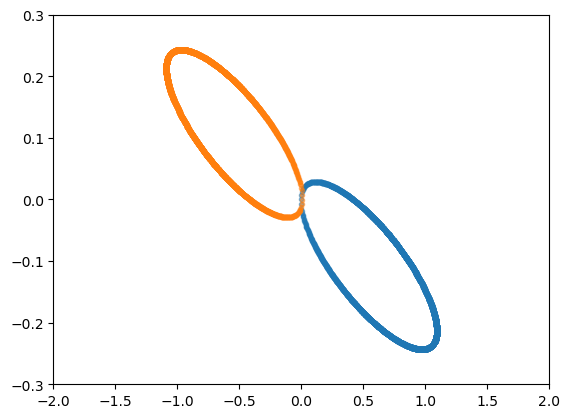

In [146]:
plt.scatter(m1_rows['x'],m1_rows['y'], marker='.', alpha=0.5)
plt.scatter(m2_rows['x'],m2_rows['y'], marker='.', alpha=0.5)
plt.xlim(-2,2)
plt.ylim(-0.3,0.3)

In [93]:
M = m1_rows.iloc[0]['m'] + m2_rows.iloc[0]['m']
mu = (m1_rows.iloc[0]['m'] * m2_rows.iloc[0]['m'])/M

In [69]:
def theta(x1,y1,x2,y2):
    return np.arctan((y1-y2)**2/(x1-x2)**2)
def r(x1, y1, x2, y2):
    return (x1-x2)**2 + (y1-y2)**2


In [70]:
vtheta = theta(m1_rows['x'],m1_rows['y'],m2_rows['x'],m2_rows['y'])
vr = r(m1_rows['x'],m1_rows['y'],m2_rows['x'],m2_rows['y'])

In [148]:
vir = v_int_to_cms(r(0.23, 0, -0.23, 0))
print(vir)

1081276.0


In [126]:
sep = r_int_to_cm(r(0.9700436,  -0.24308753,  -0.9700436,   0.24308753))
print(sep/7e10)

292.0222308775986
